# Day 16 Visualisasi Data Kategori dan Perbandingan Grup


Tidak semua data berupa angka — banyak yang berupa **kategori** (jenis kelamin, jenjang
pendidikan, ya/tidak). Notebook ini fokus pada cara **memvisualisasikan data kategorikal** dan
**membandingkan grup** memakai data nyata performa siswa.

> 🎯 **Tujuan Pembelajaran**

> - `countplot` untuk menghitung frekuensi kategori.
> - **Grouped bar** untuk membandingkan rata-rata antar grup.
> - `boxplot` skor per grup kategori.
> - **Heatmap crosstab** untuk hubungan antar dua kategori.
> - **Stacked bar** untuk komposisi proporsi.

##  Tentang Dataset

**Students Performance in Exams** berisi 1.000 siswa dengan skor ujian Matematika, Membaca, Menulis, beserta atribut latar belakang mereka.

- **Sumber:** [Kaggle — spscientist/students-performance-in-exams](https://www.kaggle.com/datasets/spscientist/students-performance-in-exams)
- **Jumlah data:** 1.000 baris × 8 kolom

| Kolom | Arti |
|-------|------|
| `gender` | Jenis kelamin |
| `race/ethnicity` | Kelompok (grup A–E, anonim) |
| `parental level of education` | Jenjang pendidikan orang tua |
| `lunch` | Tipe makan siang (standard / free-reduced) |
| `test preparation course` | Ikut kursus persiapan? (completed / none) |
| `math score`, `reading score`, `writing score` | Skor ujian (0–100) |

## 1.Import Library

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## 2.Import Dataset

In [4]:
!pip install -q kaggle
!kaggle datasets download -d spscientist/students-performance-in-exams
#!unzip -qq ecommerce-data.zip


Dataset URL: https://www.kaggle.com/datasets/spscientist/students-performance-in-exams
License(s): unknown
100% 8.70k/8.70k [00:00<00:00, 19.0MB/s]



## 3.Eksplorasi awal dataset

In [5]:
df = pd.read_csv('students-performance-in-exams.zip')
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [10]:
df["avg_score"]= df[["math score", "reading score", "writing score"]].mean(axis=1)

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
math score,1000.0,66.089000,15.163080,0.0,57.000000,66.000000,77.000000,100.0
reading score,1000.0,69.169000,14.600192,17.0,59.000000,70.000000,79.000000,100.0
writing score,1000.0,68.054000,15.195657,10.0,57.750000,69.000000,79.000000,100.0
avg_score,1000.0,67.770667,14.257326,9.0,58.333333,68.333333,77.666667,100.0


**Interpretasi:**
  - **1.000 baris** × **8 kolom**, tanpa nilai kosong. Kolom kategori bertipe
`object`, skor bertipe `int64`.
  - Rata-rata ketiga skor berada di kisaran 66–69. Kolom baru `avg_score`
(rata-rata 3 mapel) akan kita pakai sebagai ringkasan performa tiap siswa.

## 4.Frekuensi: countplot

### Grafik 1 : Countplot beberapa Categori

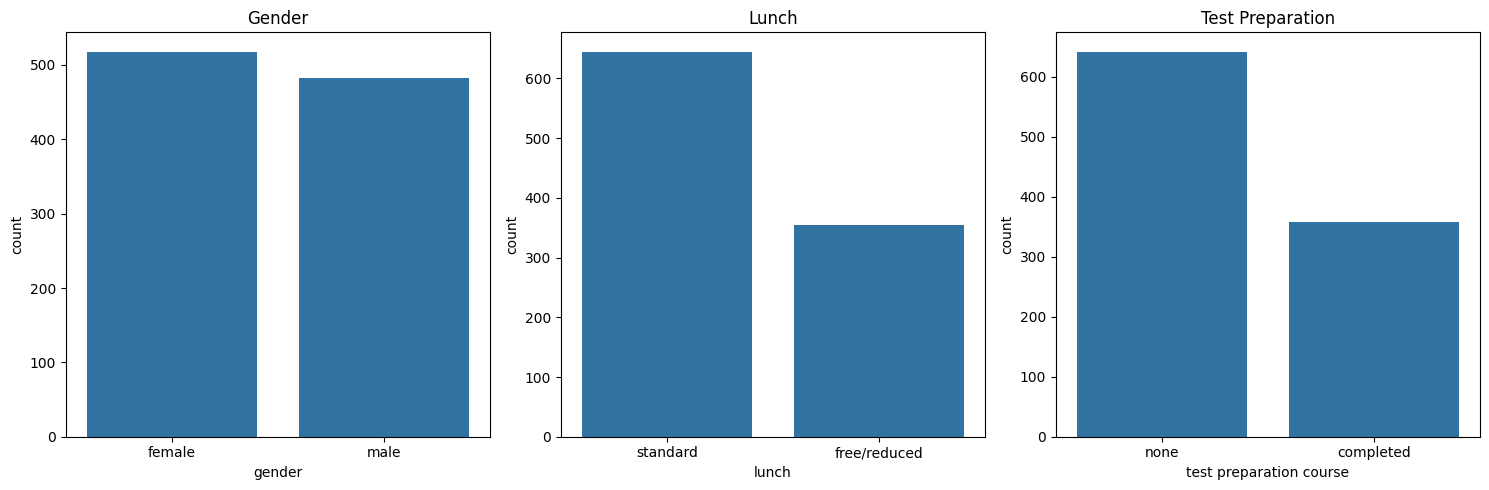

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
#1 gender
sns.countplot(data=df, x='gender', ax=axes[0])
axes[0].set_title('Gender')

#2 lucnh tipe
sns.countplot(data=df, x='lunch', ax=axes[1])
axes[1].set_title('Lunch')


#3 test preparation
sns.countplot(data=df, x='test preparation course', ax=axes[2])
axes[2].set_title('Test Preparation')

plt.tight_layout()
plt.show()

Interpretasi:
  - Jumlah siswa laki laki dan perempuan hampir imbang
  - mayoritas memakan makan siang standard
  - mayoritas juga tidak mengikuti test preparation

  memahami tiap komposisi ini penting sebelum membandingkan performa tiap grup

##5.Perbandingan Rata rata antar grup : Grouped Bar



Apakah kursus persiapan & jenis kelamin memengaruhi skor? Kita pakai `barplot` dengan `hue` untuk membuat **grouped bar** rata-rata skor.

### Grafik 2 : Grouped Bar: Rata-rata Skor per Gender & test prep

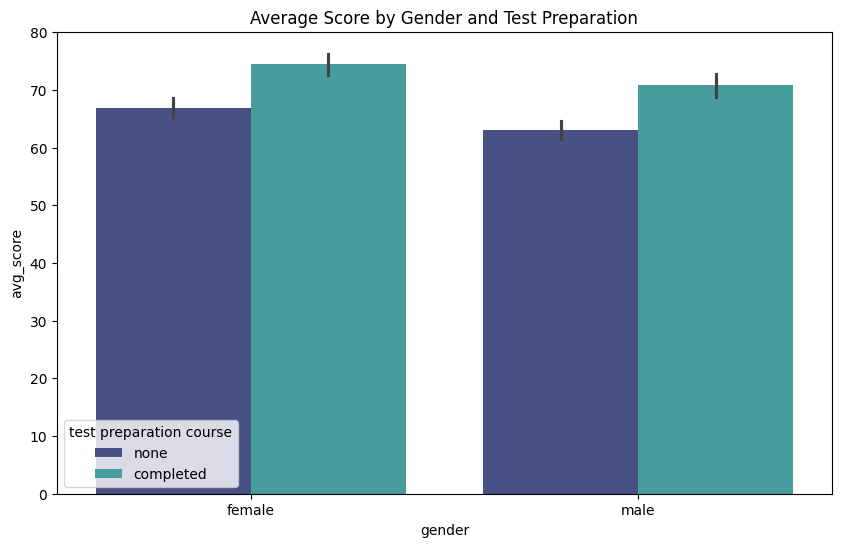

In [18]:
plt.figure(figsize=(10, 6))

sns.barplot(data=df,
            x="gender",
            y="avg_score",
            hue="test preparation course",
            palette="mako")
plt.title('Average Score by Gender and Test Preparation')
plt.show()

Interpretasi:
- siswa yang menyelesaikan kursus persiapan (completed), mempunyai nilai rata rata skor lebih tinggi dibanding yang tidak mengikuti kursus
- mengidikasikan adanya dampak positiv ikut/tidaknya kursus persiapan

##6.Sebaran Score per Grup: (boxplot)
`boxplot` menunjukkan median & sebaran skor tiap grup — lebih kaya dari sekadar rata-rata.

### Grafik 3 : Boxplot skor matematika per jenjang pendidikan orang tua

/tmp/ipykernel_2014/3964179516.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,


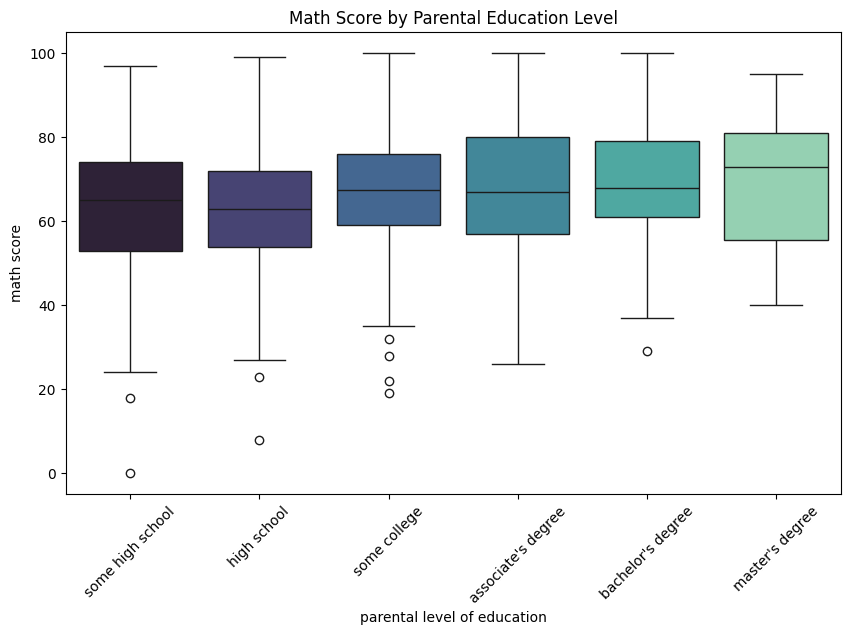

In [22]:
plt.figure(figsize=(10, 6))
urutan_pendidikan = ["some high school", "high school", "some college", "associate's degree", "bachelor's degree", "master's degree"]
sns.boxplot(data=df,
            x="parental level of education",
            y="math score",
            order=urutan_pendidikan,
            palette="mako")

plt.xticks(rotation=45)
plt.title('Math Score by Parental Education Level')
plt.show()

Interpretasi:
  - ada tren naik dilihat dari media tiap boxplot
  - mengindikasikan jenjang pendidikan orang tua berpengaruh terhadap nilai skor rata rata siswa

### Grafik 4 : Boxplot skor Membaca dan gender

/tmp/ipykernel_2014/78587217.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,


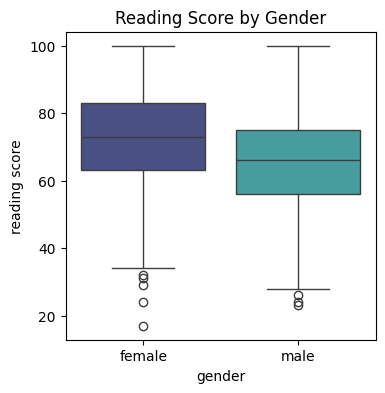

In [26]:
plt.figure(figsize=(4,4))

sns.boxplot(data=df,
            x="gender",
            y="reading score",
            palette="mako")

plt.title('Reading Score by Gender')
plt.show()

Interpretasi:
- Minat baca siswa laki laki cenderung lebih rendah daripada minta baca siswa perempuan

##7.Hubungan 2 kategori: Heatmap Crosstab


`pd.crosstab` menghitung tabel kontingensi (jumlah kombinasi dua kategori).

 Kita visualkan sebagai heatmap untuk melihat hubungan **lunch × test preparation course**.


### Grafik 5 : Heatmap crosstab lunch x test prep

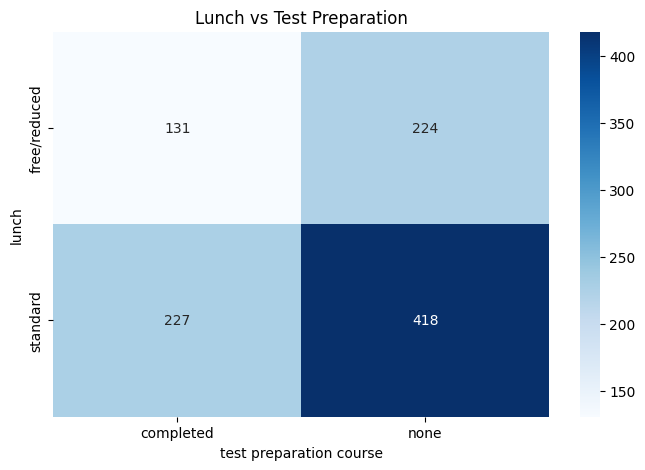

In [28]:
crss_tb = pd.crosstab(df['lunch'], df['test preparation course'])
plt.figure(figsize=(8, 5))


sns.heatmap(crss_tb, annot=True, fmt='d', cmap='Blues')
plt.title('Lunch vs Test Preparation')
plt.show()

**Interpretasi:**
  - Angka di tiap sel = jumlah siswa pada kombinasi tersebut. Terlihat siswa
dengan lunch **standard** jauh lebih banyak, dan mayoritas siswa (apa pun tipe lunch-nya) **tidak** mengikuti kursus persiapan.
  - Heatmap memudahkan membaca tabel silang.

##8.Komposisi Proporsi : StackedBar

**Stacked bar** menampilkan komposisi proporsi satu kategori di dalam kategori lain. Kita lihat proporsi status kursus persiapan untuk tiap tipe lunch.

###Grafik 6 : StackedBar proporsi  test preparation per lauch

In [30]:
propotion = pd.crosstab(df['lunch'], df['test preparation course'],
                        normalize="index")

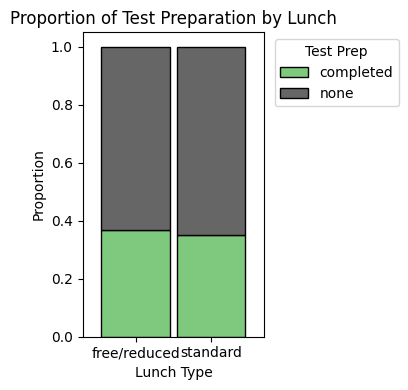

In [39]:
propotion.plot(kind="bar",
               stacked=True,
               figsize=(4,4),
               colormap="Accent",
               edgecolor="black",
               width=0.9
               )

plt.title('Proportion of Test Preparation by Lunch')
plt.xlabel('Lunch Type')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.legend(title="Test Prep", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

**Interpretasi:**
  - Proporsi yang menyelesaikan kursus persiapan **mirip** di kedua tipe lunch(sekitar sepertiga).

  - Artinya, akses ke kursus persiapan tidak terlalu berbeda antara siswa
lunch standard dan free/reduced — temuan yang menarik untuk kebijakan sekolah.

## Kesimpulan & Insight

- Untuk data kategorikal, andalkan: `countplot` (frekuensi), **grouped bar** (banding rata-rata),
  `boxplot` (sebaran per grup), **heatmap crosstab** & **stacked bar** (hubungan/komposisi).
- Temuan pada data siswa:
  - **Kursus persiapan** konsisten menaikkan skor di semua gender.
  - **Pendidikan orang tua** berkorelasi positif dengan skor anak.
- Memilih grafik yang tepat membuat perbandingan antar grup mudah dipahami audiens.

Keterampilan ini melengkapi modul visualisasi sebelum masuk ke Machine Learning.

## 💡 Insight & Jebakan Data

Memilih grafik kategorikal yang tepat membuat **perbandingan antar kelompok** langsung terbaca —
penting saat menyampaikan temuan tentang kesetaraan/akses ke audiens non-teknis.

### ⚠️ Jebakan Data
- **Jumlah** (`countplot`) berbeda dari **proporsi**. Saat ukuran grup tak seimbang, bandingkan
  **persentase** (crosstab `normalize`), bukan jumlah mentah — kalau tidak, grup besar selalu "menang".
